In [2]:
import os
import pickle
import sys
from asyncore import compact_traceback
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

# Import project modules
# from src.datagen import mackey_glass, generate_narma_data
# from src.datagen import split_and_scale_series, split_time_series, fit_minmax_scaler, transform_with_minmax_scaler
# from src.models import draw_circuit, gqnn_shape
from core.model.models import GQNN
from core.trainers.hyperparameter_trainer import HyperparameterTrainer
from core.trainers.basic_trainer import BasicTrainer
# from projects.expr_train_theory.qfim.core import compute_pure_state_qfim, diagnose_qfim
from core.model.models import GQNN
from tests.led_depth_sweep import (
    sweep_led_by_depth,
    plot_led_depth_sweep,
    is_non_decreasing_with_tolerance,
    load_trained_prefix
)
from tests.ged_depth_sweep import (
    is_non_decreasing_with_tolerance,
    plot_ged_depth_sweep,
    sweep_ged_by_depth,
)
from tests.utility import *
# from utils.Charts import multi_plot_flat_ts

from pennylane import numpy as np
import torch
from torch import nn
import pennylane as qml
from torch.utils.data import TensorDataset
import optuna

%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -optuna

### Constants
SEED = 2025
FIGURES_DIR = Path("results")  # Results will be saved in the data folder
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim = "default.qubit"  # 'default.qubit' #
interface = "torch"  # 'torch' #
diff_method = (
    "adjoint"  # as we use QRC and no training # 'adjoint' # 'parameter-shift' #
)
level = "gradient"
shots = None

dtype = torch.float64
torch.set_default_dtype(dtype)

# Enable CUDA device if available
torch_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nThe optimal devices: {sim} and {torch_device}")

Project root: /home/adrian
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

The optimal devices: default.qubit and cpu


# 1. Model training

In [8]:
dataset_path = Path(project_root) / "Coding-projects" / "TDS_ED_repository" / "core" / "datasets"

chart_name = "Mackey_Glass_tau_30"
training_path = dataset_path / f"train_dataset_{chart_name}.pt"
validating_path = dataset_path / f"val_dataset_{chart_name}.pt"
test_path = dataset_path / f"test_dataset_{chart_name}.pt"

trainer = BasicTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=test_path,
    criterion=nn.MSELoss(),
)

In [9]:
model_config = {
    "n_layers": 10,
    "n_qubits": 4,
    "quantum_device": "lightning.qubit",
    "interface": "torch",
    "diff_method": "best",
    "fm_style": "iqp",
    "meas": [0],
}

training_config = {
    "number_of_training_workers": 4,
    "number_of_validating_workers": 2,
    "number_of_testing_workers": 2,
    "batch_size": 1,
    "device": "cpu",
    "epochs": 20,
    "optimizer": {
        "name": "Adam",
        "lr": 0.0004932767530689781,
        "momentum": 0.0,
        "weight_decay": 1.0850502895471054e-05,
    },
    "regularization": {
        "type": None,
        "lambda": None,
    },
}

config = {
    "model_config": model_config,
    "training_config": training_config,
}

net, training_metrics = trainer.train_model(config, GQNN)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

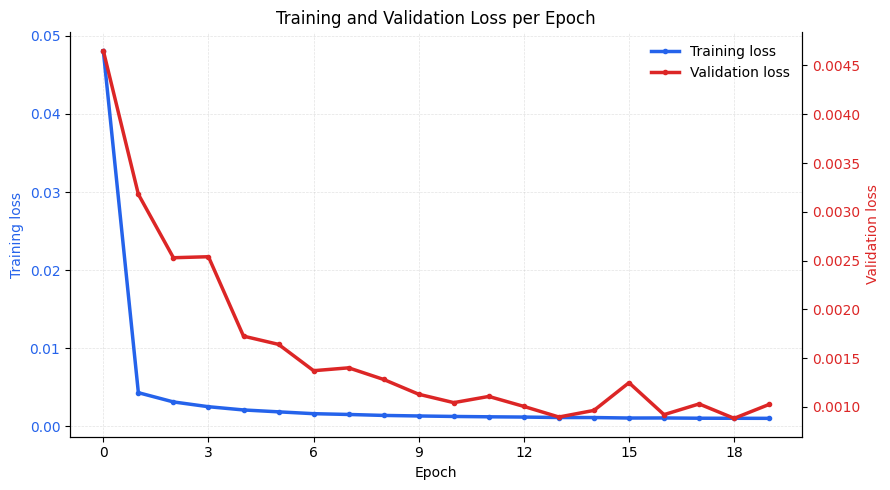

In [10]:
training_loss = training_metrics["training_loss"]
validating_loss = training_metrics["validating_loss"]
epochs = range(len(training_loss))

fig, ax_train = plt.subplots(figsize=(9, 5))
ax_valid = ax_train.twinx()

train_line = ax_train.plot(
    epochs,
    training_loss,
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Training loss",
)

valid_line = ax_valid.plot(
    epochs,
    validating_loss,
    color="#DC2626",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Validation loss",
)

ax_train.set_title("Training and Validation Loss per Epoch")
ax_train.set_xlabel("Epoch")

ax_train.set_ylabel("Training loss", color="#2563EB")
ax_valid.set_ylabel("Validation loss", color="#DC2626")

ax_train.tick_params(axis="y", labelcolor="#2563EB")
ax_valid.tick_params(axis="y", labelcolor="#DC2626")

ax_train.grid(True, linestyle="--", alpha=0.35)
ax_train.spines["top"].set_visible(False)
ax_valid.spines["top"].set_visible(False)

lines = train_line + valid_line
ax_train.legend(lines, [line.get_label() for line in lines], frameon=False)
ax_train.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()
plt.show()

# 2. Local and global effective dimension sweep

In [11]:
trained_depth = model_config["n_layers"]
n_qubits = model_config["n_qubits"]

def model_factory(depth):
    return GQNN(
        n_layers=depth,
        n_qubits=n_qubits,
        quantum_device=qml.device(
            "default.qubit",
            wires=n_qubits,
        ),
        interface="torch",
        diff_method="best",
        fm_style="iqp",
        meas=[0],
    )


def trained_model_factory(depth):
    if depth < 1:
        raise ValueError("depth must be at least 1")

    if depth > trained_depth:
        raise ValueError(
            f"Cannot obtain a trained depth-{depth} model from a "
            f"trained depth-{trained_depth} model."
        )

    depth_net = GQNN(
        n_layers=depth,
        n_qubits=n_qubits,
        quantum_device=qml.device(
            "default.qubit",
            wires=n_qubits,
        ),
        interface=model_config["interface"],
        diff_method=model_config["diff_method"],
        fm_style=model_config["fm_style"],
        meas=model_config["meas"],
    )

    load_trained_prefix(depth_net, net)

    return depth_net

Computing LED sweep:   0%|          | 0/50 [00:00<?, ?evaluation/s]

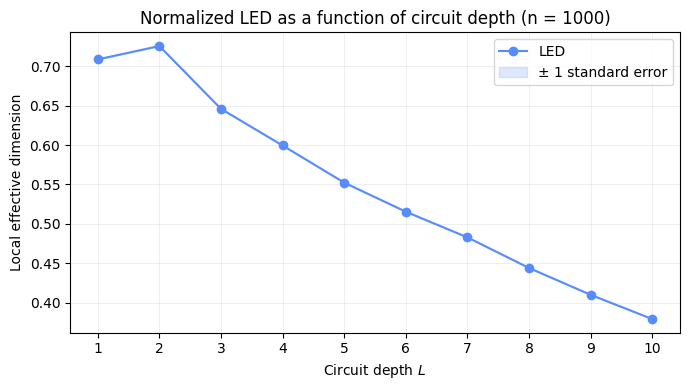

In [12]:
depths = range(1, trained_depth + 1)

test_dataset = torch.load(
    test_path,
    map_location="cpu",
    weights_only=False,
)

test_inputs = test_dataset.tensors[0].detach().clone()
inputs = test_inputs.to(
    device="cpu",
    dtype=torch.get_default_dtype(),
)


led_result = sweep_led_by_depth(
    model_factory=trained_model_factory,
    inputs=inputs,
    depths=depths,
    theoretical_dataset_size=1_000,
    n_theta=100,
    epsilon=0.1,
    repetitions=5,
    normalize=True,
    seed=0,
    min_probability=1e-12,
)

plot_led_depth_sweep(
    led_result,
    output_path="trained_prefix_led_by_depth.pdf",
)

Computing GED sweep:   0%|          | 0/50 [00:00<?, ?evaluation/s]

[0.689553598113457, 0.713682746880426, 0.6317275769773257, 0.5922303651847831, 0.5550699575676055, 0.5023886841511341, 0.46916792149532, 0.44043739119355996, 0.40999441398865477, 0.3887522760392569]


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Normalized GED as a function of circuit depth (n = 1000)'}, xlabel='Circuit depth $L$', ylabel='Normalized global effective dimension'>)

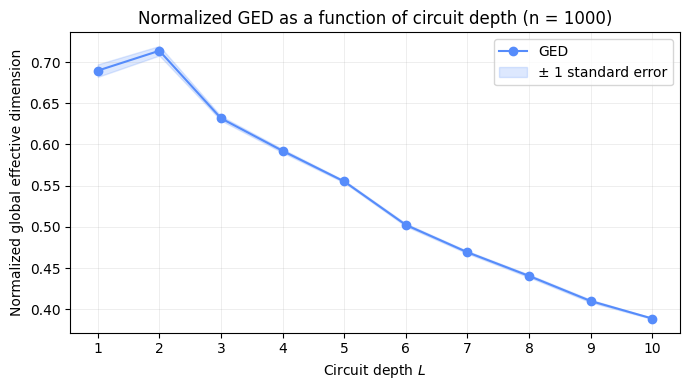

In [14]:
ged_result = sweep_ged_by_depth(
    model_factory=model_factory,
    inputs=inputs,
    depths=list(range(1,trained_depth+1)),
    theoretical_dataset_size=1_000,
    n_theta=10,
    normalize=True,
    repetitions=5,
    seed=0,
)

print(ged_result.means)

plot_ged_depth_sweep(
    ged_result,
    output_path="results/ged_depth_sweep.png",
)

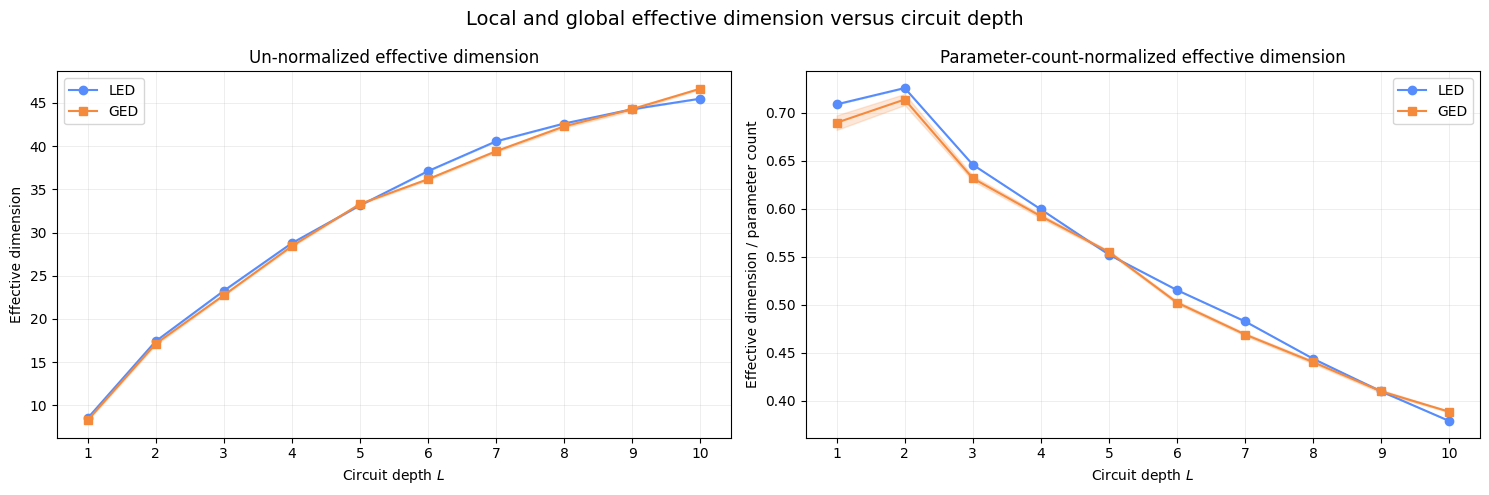

In [21]:
figure, axes = plot_effective_dimension_depth_sweep(
    led_result=led_result,
    ged_result=ged_result,
    model_factory=model_factory,
    output_path="results/effective_dimension_depth_sweep.pdf",
)

figure.savefig(
    "results/effective_dimension_depth_sweep.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [22]:
import pickle

with open("trained_prefix_led_ged_results.pkl", "wb") as f:
    pickle.dump(
        {
            "led_result": led_result,
            "ged_result": ged_result,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )